<a href="https://colab.research.google.com/github/yg36/LangGraph-Learnings/blob/main/Langgraph_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
  name: str
  age: int
  skills: List[str]
  message: str

In [ ]:
def greet(state: AgentState) -> AgentState:
  state['message'] = f"Hi {state['name']}! "


  return state

In [ ]:
def age(state: AgentState) -> AgentState:
  state['message'] = state['message'] + f"Your age is {state['age']}."

  return state

In [ ]:
def skills(state: AgentState) -> AgentState:
  state['message'] = state['message'] + "Your skills are:"
  for skill in state['skills']:
    state['message'] = state['message'] + f" {skill} "

  return state

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greet node", greet)
graph.add_node("age node", age)
graph.add_node("skills node", skills)

graph.add_edge("greet node", "age node")
graph.add_edge("age node", "skills node")

graph.set_entry_point("greet node")
graph.set_finish_point("skills node")

app = graph.compile()

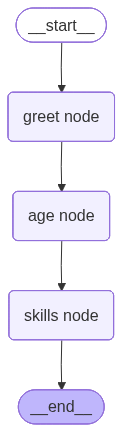

In [ ]:
app

In [ ]:
results = app.invoke({"name": "YG", "age": 20, "skills": ["Python", "ML", "AI", "C++"]})

In [ ]:
results

{'name': 'YG',
 'age': 20,
 'skills': ['Python', 'ML', 'AI', 'C++'],
 'message': 'Hi YG! Your age is 20.Your skills are: Python  ML  AI  C++ '}

In [ ]:
results['message']

'Hi YG! Your age is 20.Your skills are: Python  ML  AI  C++ '